In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from langdetect import detect
import re
import emoji
from pathlib import Path
import os

In [2]:
# ================= PROJECT ROOT & DATA PATHS =================
try:
    PROJECT_ROOT = Path(__file__).resolve().parent
except NameError:
    PROJECT_ROOT = Path.cwd()  # fallback if running interactively

DEFAULT_DATA_DIR = Path(r"C:/Users/DELL/Documents/project_data/output")
DATA_DIR = Path(os.getenv("DATA_DIR", DEFAULT_DATA_DIR))

POSTS_PATH = DATA_DIR / "safaricom_posts.csv"
COMMENTS_PATH = DATA_DIR / "safaricom_comments22.csv"

# ================= FILE EXISTENCE CHECK =================
print("Using DATA_DIR:", DATA_DIR)
if not POSTS_PATH.exists():
    raise FileNotFoundError(f"Posts file not found: {POSTS_PATH}")
if not COMMENTS_PATH.exists():
    raise FileNotFoundError(f"Comments file not found: {COMMENTS_PATH}")

# ================= LOAD CSVs =================
posts = pd.read_csv(POSTS_PATH)
comment = pd.read_csv(COMMENTS_PATH)

# ================= KEEP text + sender_id =================
comments = (
    comment[['sender_id', 'text']]
    .dropna(subset=['text'])
    .reset_index(drop=True)
)

#================== DATA INSPECTION =================
print("\n=== BEFORE PREPROCESSING ===")
print(f"Posts shape: {posts.shape}")
print(f"Comments shape: {comment.shape}")
print("\nPosts columns:", posts.columns.tolist())
print("Comments columns:", comment.columns.tolist())

print("\n------ For Sentiment Analysis ------")
print(f"Comments shape: {comments.shape}")


Using DATA_DIR: C:\Users\DELL\Documents\project_data\output

=== BEFORE PREPROCESSING ===
Posts shape: (1948, 11)
Comments shape: (286376, 5)

Posts columns: ['msg_id', 'date_utc', 'text', 'views', 'forwards', 'replies', 'has_media', 'media_type', 'sender_id', 'reply_to_msg_id', 'num_comments']
Comments columns: ['post_id', 'comment_id', 'date_utc', 'text', 'sender_id']

------ For Sentiment Analysis ------
Comments shape: (279536, 2)


In [3]:
 # ---------- Check for missing values in 'text' column ----------
print("\nMissing values per column (comments):")
print(comments.isna().sum())
print("\nSample comments:")
print(comments.head())


Missing values per column (comments):
sender_id    32160
text             0
dtype: int64

Sample comments:
      sender_id                                               text
0  5.436407e+09  እካ ሰላምታ ....... በምንትያ\nበዳጣ .....ምናለ በዳጣ\nካስደሰኳ...
1           NaN  ሰላም Melak፣ 🎉ለተሳትፎዎ እናመሰግናለን! የእንካ ሰላምታ ጨዋታ ተጠና...
2  1.764658e+09  እንካ ሰላምታ.....በምንቲያ ?\nበ ገርጂ ...... ምን አለ በ ገርጂ...
3           NaN  እንኳን ደስ አሎት🎉! Haf ማን፣ በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ...
4           NaN  እንኳን ደስ አሎት🎉! በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ ስላሳዩ እና...


=== COMMENT TYPE DISTRIBUTION ===


,count,percentage
comment_type,,
Text only,203771,72.90
Text + Emoji,52974,18.95
Empty/Other,18820,6.73
Emoji only,3971,1.42


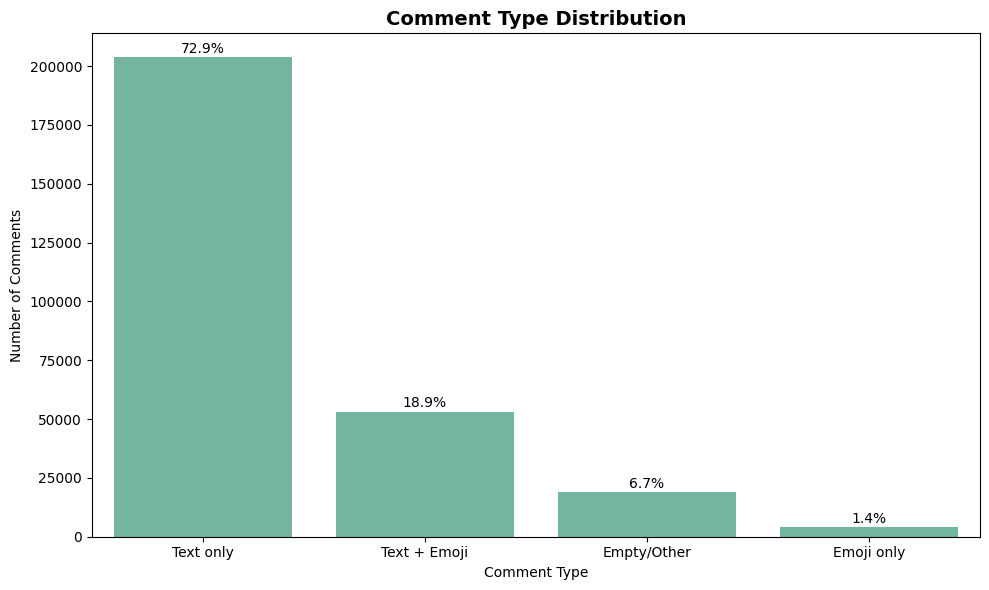

In [4]:
# ------------------------------
# 1. Classification directly from 'text' column (no new cleaned_text)
# ------------------------------
AMHARIC_RE = re.compile(r'[\u1200-\u137F]')
ENGLISH_RE = re.compile(r'[A-Za-z]')

def contains_emoji(text: str) -> bool:
    return bool(emoji.emoji_list(text))

def classify_comment_type(text: str) -> str:
    text = str(text).strip()
    if not text:
        return 'Empty/Other'
    has_amharic = bool(AMHARIC_RE.search(text))
    has_english = bool(ENGLISH_RE.search(text))
    has_text = has_amharic or has_english
    has_emoji = contains_emoji(text)
    
    if has_text and has_emoji:
        return 'Text + Emoji'
    elif has_text:
        return 'Text only'
    elif has_emoji:
        return 'Emoji only'
    else:
        return 'Empty/Other'

# Apply classification on original 'text'
comments['comment_type'] = comments['text'].apply(classify_comment_type)

# ------------------------------
# 2. Distribution
# ------------------------------
comment_type_counts = comments['comment_type'].value_counts()
comment_type_percent = (comment_type_counts / len(comments) * 100).round(2)

summary_df = pd.DataFrame({
    'count': comment_type_counts,
    'percentage': comment_type_percent
}).sort_values('count', ascending=False)

print("=== COMMENT TYPE DISTRIBUTION ===")
display(summary_df)

# ------------------------------
# 3. Visualization
# ------------------------------
plt.figure(figsize=(10, 6))
palette_colors = sns.color_palette('Set2', n_colors=len(summary_df))

sns.barplot(
    x=summary_df.index,
    y=summary_df['count'],
    color=palette_colors[0]
)

plt.title('Comment Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Comment Type')
plt.ylabel('Number of Comments')

for i, v in enumerate(summary_df['count']):
    pct = summary_df['percentage'].iloc[i]
    plt.text(i, v + max(summary_df['count']) * 0.01, f"{pct:.1f}%", 
             ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [5]:
import emoji

# -------------------------------------------------
# 1. Select Emoji only + Empty/Other together
# -------------------------------------------------
mask = comments['comment_type'].isin(['Empty/Other'])
emoji_empty_df = comments[mask].copy()

# -------------------------------------------------
# 2. Count number of comments
# -------------------------------------------------
total_count = len(emoji_empty_df)

print("=== CHECK EMOJI IN EMPTY/OTHER ===")
print(f"Total comments in this group: {total_count}\n")

# -------------------------------------------------
# 3. Count how many emojis exist inside this group
# -------------------------------------------------
def count_emojis(text):
    return len(emoji.emoji_list(str(text)))

total_emojis = emoji_empty_df['text'].apply(count_emojis).sum()

print(f"Total emojis inside these comments: {total_emojis}\n")

=== CHECK EMOJI IN EMPTY/OTHER ===
Total comments in this group: 18820

Total emojis inside these comments: 0



In [6]:
# -----------------------------
# Show sample 'Empty/Other' comments
# -----------------------------
sample_empty = comments[comments['comment_type'] == 'Empty/Other']['text'].tail(10)

print("=== SAMPLE EMPTY/OTHER COMMENTS ===")
for i, txt in enumerate(sample_empty, 1):
    print(f"{i}. {txt}")

# 3. Process as requested
# Drop Empty/Other because there is no any emojis and it is not useful for our analysis
comments = comments[comments['comment_type'] != 'Empty/Other'].copy()
comments = comments.reset_index(drop=True)   # <-- This fixes the problem

print(f"Final after dropping Empty/Other comments shape: {comments.shape}")

=== SAMPLE EMPTY/OTHER COMMENTS ===
1. 3,141
2. 2700
3. 3000
4. 300
5. 3000
6. 3000
7. 0722579432
8. 0722737398
9. 0723182506
10. 100%
Final after dropping Empty/Other comments shape: (260716, 3)


In [7]:
# ==========================================================
# UNIQUE EMOJI EXTRACTION FROM "EMOJI ONLY" COMMENTS
# ==========================================================

import pandas as pd
import emoji

# 1. Select Emoji Only comments and get their text
emoji_only_comments = comments[comments['comment_type'] == 'Emoji only']['text'].astype(str)
emoji_only = comments['text'].astype(str)

# 2. Collect emojis
emoji_occurrences = []   # for frequency
emoji_unique_set = set() # for true unique emojis

for text in emoji_only:
    found = emoji.emoji_list(text)
    
    # emojis in this comment (may repeat)
    emojis_in_comment = [e['emoji'] for e in found]
    
    # Add to frequency list
    emoji_occurrences.extend(emojis_in_comment)
    
    # Add to unique set (no duplicates)
    emoji_unique_set.update(emojis_in_comment)

# 3. Frequency count
emoji_freq = pd.Series(emoji_occurrences).value_counts()

# 4. Unique emojis list
unique_emojis = sorted(list(emoji_unique_set))

print("=== EMOJI ANALYSIS FROM 'EMOJI ONLY' COMMENTS ===")
print(f"Total Emoji Only comments      : {len(emoji_only_comments)}")
print(f"Total emoji occurrences        : {len(emoji_occurrences)}")
print(f"Total UNIQUE emoji symbols     : {len(unique_emojis)}\n")

print("=== TOP 20 MOST USED EMOJIS ===")
print(emoji_freq.head(5))

print("\n=== ALL UNIQUE EMOJIS USED ===")
#print(unique_emojis)  # Show first 20 unique emojis ((unique_emojis[:20]))
print(unique_emojis[500:520])

=== EMOJI ANALYSIS FROM 'EMOJI ONLY' COMMENTS ===
Total Emoji Only comments      : 3971
Total emoji occurrences        : 633631
Total UNIQUE emoji symbols     : 1040

=== TOP 20 MOST USED EMOJIS ===
🖕    338327
😁     20695
👌     18719
🥰     16126
🙌     13011
Name: count, dtype: int64

=== ALL UNIQUE EMOJIS USED ===
['💕', '💖', '💗', '💘', '💙', '💚', '💛', '💜', '💝', '💞', '💟', '💠', '💡', '💣', '💥', '💦', '💧', '💨', '💩', '💪']


In [8]:
print(f"Comments shape: {comments.shape}")
comments.tail(10)

Comments shape: (260716, 3)


,sender_id,text,comment_type
260706,7.968480e+09,"Hello, Currently, we have not yet launched the...",Text only
260707,7.968480e+09,ሰላም፣ እባክዎ ሙሉ ስም ከነአያት እና ስልክ ቁጥሮን በውስጥ መስመር @S...,Text only
260708,7.968480e+09,ሰላም፣ እባክዎ ጉዳይዎን አብራርተው ይፃፉልን። ^FD,Text only
260709,8.494840e+09,Yene abat😭😭😭😭😭😭😭,Text + Emoji
260710,6.458000e+09,Pubg package ይምጣልን,Text only
260711,7.373734e+09,ከቴሌ የባሳችሁ ሌቦች! ጥሩ ነገር ያመጣችሁ መስሎኝ ሄጄ ማየቴ!,Text only
260712,8.095371e+09,UCH6MKWQ1A ?,Text only
260713,8.664135e+09,ሰላም ጤና ይስጥልኝ ውድ የሳፋሪኮም ሰራተኞች በሙሉ ሁለመናችሁ ከዳታ እስ...,Text only
260714,7.134093e+09,ችግሩ ውድ ነው መጠቀም ፈልገን ነበር ከቴሌ ባሳችሁ ሌብነት,Text only
260715,7.669047e+09,እረ ማብራቱን አሰተካክሉልኝ,Text only


In [9]:
#========================= language detection =========================
# Detect if text is Amharic, English, or mixed
#======================================================================

from wordfreq import zipf_frequency

def detect_language_simple(text):
    """
    Detect language of comment using character ranges
    Fast and works well for Amharic-English mixed text
    """
    if not isinstance(text, str) or len(text.strip()) < 2:
        return 'unknown/other'
    
    text = str(text).strip()
    
    # Count Amharic characters (Unicode range: ሀ to ፐ)
    amharic_chars = re.findall(r'[\u1200-\u137F]', text)
    amharic_count = len(amharic_chars)
    
    # Count English characters (a-z, A-Z)
    english_chars = re.findall(r'[a-zA-Z]', text)
    english_count = len(english_chars)
    
    # Count total meaningful characters (exclude spaces, punctuation)
    total_meaningful = amharic_count + english_count
    
    if total_meaningful == 0:
        return 'unknown/other'
    
    # Calculate percentages
    amharic_pct = amharic_count / total_meaningful
    english_pct = english_count / total_meaningful
    
    # Classify based on thresholds
    if amharic_pct > 0.8:
        return 'amharic'
    elif english_pct > 0.8:
        return 'english'
    elif amharic_pct > 0.2 and english_pct > 0.2:
        return 'mixed'
    else:
        return 'unknown/other'

# Apply to your data
comments['language'] = comments['text'].apply(detect_language_simple)

# Get distribution
lang_distribution = comments['language'].value_counts()
print("=== LANGUAGE DISTRIBUTION ===")
print(lang_distribution)
print(f"\nTotal: {len(comments)} comments")

# Calculate percentages
print("\n=== PERCENTAGES ===")
for lang, count in lang_distribution.items():
    percentage = (count / len(comments)) * 100
    print(f"{lang:15}: {count:8,} ({percentage:5.2f}%)")
# ============================================================
# TRUE ENGLISH vs ROMANIZED AMHARIC DETECTION (ONE CELL)
# ============================================================

# ---------------------------------------
# 1. English vocabulary checker
# ---------------------------------------
def is_english_word(word: str) -> bool:
    """
    Returns True if word is common English vocabulary.
    zipf > 3 => common English word
    """
    return zipf_frequency(word.lower(), 'en') > 3


# ---------------------------------------
# 2. Measure English vocabulary coverage
# ---------------------------------------
def english_vocab_ratio(text: str) -> float:
    words = re.findall(r'[a-zA-Z]+', str(text).lower())
    if not words:
        return 0.0
    
    english_like = sum(is_english_word(w) for w in words)
    return english_like / len(words)


# ---------------------------------------
# 3. Separate True English vs Romanized
# ---------------------------------------
def classify_english_or_roman(text: str) -> str:
    ratio = english_vocab_ratio(text)
    
    # Thresholds based on research observation
    if ratio >= 0.6:
        return 'True English'
    elif ratio <= 0.2:
        return 'Romanized Amharic'
    else:
        return 'Mixed/Uncertain'


# ---------------------------------------
# 4. Apply ONLY on comments detected as 'english'
#    from your previous language detection
# ---------------------------------------
english_comments = comments[comments['language'] == 'english'].copy()

english_comments['eng_ratio'] = english_comments['text'].apply(english_vocab_ratio)
english_comments['english_type'] = english_comments['text'].apply(classify_english_or_roman)


# ---------------------------------------
# 5. Statistics
# ---------------------------------------
counts = english_comments['english_type'].value_counts()
percent = counts / len(english_comments) * 100

print("=== ENGLISH GROUP ANALYSIS ===")
for k in counts.index:
    print(f"{k:20}: {counts[k]:8,} ({percent[k]:5.2f}%)")


# ---------------------------------------
# 6. Show samples of Romanized Amharic
# ---------------------------------------
print("\n=== SAMPLE ROMANIZED AMHARIC COMMENTS ===")
samples = english_comments[english_comments['english_type'] == 'Romanized Amharic']['text'].head(5)

for i, txt in enumerate(samples, 1):
    print(f"{i}. {txt}")

=== LANGUAGE DISTRIBUTION ===
language
amharic          124072
english           90974
unknown/other     25865
mixed             19805
Name: count, dtype: int64

Total: 260716 comments

=== PERCENTAGES ===
amharic        :  124,072 (47.59%)
english        :   90,974 (34.89%)
unknown/other  :   25,865 ( 9.92%)
mixed          :   19,805 ( 7.60%)
=== ENGLISH GROUP ANALYSIS ===
True English        :   48,769 (53.61%)
Romanized Amharic   :   24,751 (27.21%)
Mixed/Uncertain     :   17,454 (19.19%)

=== SAMPLE ROMANIZED AMHARIC COMMENTS ===
1. hhh🤌🤌🤌
2. Kkkkkkk
3. Beminitiya
4. Enka selamta
5. Lemen atetebaberegnem wendem


In [10]:
# ---------------------------------------
# 6. Show samples for all categories
# ---------------------------------------
print("\n=== SAMPLE COMMENTS BY CATEGORY (First 8 each) ===")

categories = ['True English']

for cat in categories:
    print(f"\n--- {cat} ---")
    samples = english_comments[english_comments['english_type'] == cat]['text'].head(5)
    
    if len(samples) == 0:
        print("No samples found for this category.")
    else:
        for i, txt in enumerate(samples, 1):
            print(f"{i}. {txt[:150]}{'...' if len(txt) > 150 else ''}")


=== SAMPLE COMMENTS BY CATEGORY (First 8 each) ===

--- True English ---
1. Hi Abu, Currently, our M-Pesa app is accessible on the Play Store for Android devices. Please ensure that your Android phone's version is higher than ...
2. Please let me know how to download and use Sefericom Ethiopia m-pesa app on my android mobile phone that doesn't work on google play and gate store?
3. The concerned team will investigate, find the comment with the most likes, and award the winner. The winner will be revealed soon. Please be patient. ...
4. Congratulations!! 🎉If you have received a message notifying that you are a winner of Kimem Awaze, our staff will contact you at the number 0700 700 70...
5. If you have received a message notifying that you are a winner of Kimem Awaze, our staff will contact you at the number 0700 700 700 at the soonest to...


In [11]:
# ---------------------------------------
# 6. Show samples for all categories
# ---------------------------------------
print("\n=== SAMPLE COMMENTS BY CATEGORY (First 8 each) ===")

categories = ['Mixed/Uncertain']

for cat in categories:
    print(f"\n--- {cat} ---")
    samples = english_comments[english_comments['english_type'] == cat]['text'].head(5)
    
    if len(samples) == 0:
        print("No samples found for this category.")
    else:
        for i, txt in enumerate(samples, 1):
            print(f"{i}. {txt[:150]}{'...' if len(txt) > 150 else ''}")


=== SAMPLE COMMENTS BY CATEGORY (First 8 each) ===

--- Mixed/Uncertain ---
1. Er Friend  ezih 3000 birr eyalun nw mnshe nw gin???
2. safaricom addisaba bicha meselachu ende hager lela bota sayders and bota bicha yemitishelimut shame on you
3. Inka selamta .... Bemintiya
Besh konbo...... Mn ale besh konbo

Yesafar com besh konbo be 15 birri 70 deqiqa letele 70 deqiqa letemesasay network 700m...
4. Hi @SafaricomET 👋
5. Bethio tele yhonal eko comment yadergshew🤭


In [12]:
# ============================================================
# FILTER COMMENTS FOR SENTIMENT ANALYSIS
# Keep: Amharic + Mixed + True English + Emoji only
# No extra columns created
# ============================================================

# 1. Temporary language detection
temp_language = comments['text'].apply(detect_language_simple)

# 2. Function to check True English (without storing column)
def is_true_english(text):
    return classify_english_or_roman(text) == 'True English'

# 3. Build masks

# Amharic and Mixed
mask_amharic_mixed = temp_language.isin(['amharic', 'mixed'])

# True English only (exclude Romanized)
mask_true_english = (
    (temp_language == 'english') &
    (comments['text'].apply(is_true_english))
)

# Emoji only comments
mask_emoji_only = comments['comment_type'] == 'Emoji only'

# 4. Combine all conditions
final_mask = mask_amharic_mixed | mask_true_english | mask_emoji_only

# 5. Create final dataframe for sentiment analysis
sentiment_df = comments[final_mask].copy()

# ============================================================
# 6. Show statistics
# ============================================================
print("=== SENTIMENT DATASET STATISTICS ===\n")

print("Amharic + Mixed :", mask_amharic_mixed.sum())
print("True English    :", mask_true_english.sum())
print("Emoji only      :", mask_emoji_only.sum())

print(f"\nTotal comments kept for sentiment analysis: {len(sentiment_df)}")

=== SENTIMENT DATASET STATISTICS ===

Amharic + Mixed : 143877
True English    : 48769
Emoji only      : 3971

Total comments kept for sentiment analysis: 196617


In [13]:
print(f"\nTotal comments for sentiment: {len(sentiment_df)}")
print(f"\nNumber of columns for sentiment: {(sentiment_df.columns)}")
print(sentiment_df.head(10))


Total comments for sentiment: 196617

Number of columns for sentiment: Index(['sender_id', 'text', 'comment_type', 'language'], dtype='object')
       sender_id                                               text  \
0   5.436407e+09  እካ ሰላምታ ....... በምንትያ\nበዳጣ .....ምናለ በዳጣ\nካስደሰኳ...   
1            NaN  ሰላም Melak፣ 🎉ለተሳትፎዎ እናመሰግናለን! የእንካ ሰላምታ ጨዋታ ተጠና...   
2   1.764658e+09  እንካ ሰላምታ.....በምንቲያ ?\nበ ገርጂ ...... ምን አለ በ ገርጂ...   
3            NaN  እንኳን ደስ አሎት🎉! Haf ማን፣ በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ...   
4            NaN  እንኳን ደስ አሎት🎉! በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ ስላሳዩ እና...   
5            NaN  እንኳን ደስ አሎት🎉! Melek፣ በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ ...   
6            NaN  Hi Abu, Currently, our M-Pesa app is accessibl...   
7            NaN  ሰላም Es፣ እኛ ካስቀመጥነው ዋጋ በላይ ከተጠየቁ እባክዎ ይህን ሊንክ @...   
8   1.146566e+09  Please let me know how to download and use Sef...   
10  6.425993e+09     እካ ስለምንትያ በምንትያ\nበውዲቷ ሀገር \nበሳፋሪ ዳታ ዘና ብለህ እደር   

    comment_type language  
0   Text + Emoji  amharic  
1   Text + Emoji 

In [14]:
import emoji

# --------------------------------------------------
# Convert ANY emoji inside text to exact text name
# --------------------------------------------------
def replace_emoji_with_text(text):
    if not isinstance(text, str):
        return text
    
    # Convert emoji to official names
    text = emoji.demojize(text, delimiters=(" ", " "))
    
    # Clean extra spaces created by conversion
    text = " ".join(text.split())
    
    return text


# --------------------------------------------------
# Apply to your column
# --------------------------------------------------
sentiment_df['clean_text'] = sentiment_df['text'].apply(replace_emoji_with_text)

# --------------------------------------------------
# Show sample
# --------------------------------------------------
print(sentiment_df[['text', 'clean_text']].head(5))

                                                text  \
0  እካ ሰላምታ ....... በምንትያ\nበዳጣ .....ምናለ በዳጣ\nካስደሰኳ...   
1  ሰላም Melak፣ 🎉ለተሳትፎዎ እናመሰግናለን! የእንካ ሰላምታ ጨዋታ ተጠና...   
2  እንካ ሰላምታ.....በምንቲያ ?\nበ ገርጂ ...... ምን አለ በ ገርጂ...   
3  እንኳን ደስ አሎት🎉! Haf ማን፣ በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ...   
4  እንኳን ደስ አሎት🎉! በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ ስላሳዩ እና...   

                                          clean_text  
0  እካ ሰላምታ ....... በምንትያ በዳጣ .....ምናለ በዳጣ ካስደሰኳቹ ...  
1  ሰላም Melak፣ party_popper ለተሳትፎዎ እናመሰግናለን! የእንካ ...  
2  እንካ ሰላምታ.....በምንቲያ ? በ ገርጂ ...... ምን አለ በ ገርጂ ...  
3  እንኳን ደስ አሎት party_popper ! Haf ማን፣ በእንካ ሰላምታ በ...  
4  እንኳን ደስ አሎት party_popper ! በእንካ ሰላምታ በመግጠም ያሎት...  


In [15]:
import re

def preprocess_text(text):
    if not isinstance(text, str) or len(text.strip()) < 2:
        return ""
    
    # 1. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # 2. Remove Numbers and IDs
    text = re.sub(r'\d+', '', text)
    
    # Keep only: letters, Amharic, spaces, ?, !
    text = re.sub(r'[^\w\s\?!ሀ-ፐ]', '', text)
    
    # 4. Remove extra repeated letters (e.g. goooood -> good)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    
    # 5. Remove emojis
    #text = re.sub(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF]+', '', text)
    
    # 6. Clean extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply preprocessing
sentiment_df['clean_text'] = sentiment_df['clean_text'].apply(preprocess_text)

print("Preprocessing completed.")
print("Sample clean text:")
print(sentiment_df['clean_text'].head(3))

Preprocessing completed.
Sample clean text:
0    እካ ሰላምታ በምንትያ በዳጣ ምናለ በዳጣ ካስደሰኳቹ ሸልሙኝ ዳታ beami...
1    ሰላም Melak party_popper ለተሳትፎዎ እናመሰግናለን! የእንካ ሰ...
2    እንካ ሰላምታበምንቲያ ? በ ገርጂ ምን አለ በ ገርጂ ?? ምንድነው እንዲ...
Name: clean_text, dtype: object


In [16]:
# ============================================================
# COUNT EMOJI DIRECTLY FROM cleaned_text (NO NEW COLUMN)
# ============================================================

def count_emoji(text):
    return len(emoji.emoji_list(str(text)))

# Total emoji in the whole column
total_emoji = sentiment_df['clean_text'].apply(count_emoji).sum()

# Number of comments that contain at least one emoji
comments_with_emoji = sentiment_df['clean_text'].apply(lambda x: count_emoji(x) > 0).sum()

print("=== EMOJI STATISTICS IN cleaned_text ===")
print(f"Total emoji occurrences : {total_emoji:,}")
print(f"Comments with emoji    : {comments_with_emoji:,}")
print(f"Comments without emoji : {len(sentiment_df) - comments_with_emoji:,}")

=== EMOJI STATISTICS IN cleaned_text ===
Total emoji occurrences : 0
Comments with emoji    : 0
Comments without emoji : 196,617


In [17]:
import nltk

nltk.download('stopwords', quiet=True)
stop_words = set(nltk.corpus.stopwords.words('english'))

# =============================================================
# FIXED & CLEAN PREPROCESSING PIPELINE
# =============================================================

def remove_short_english_tokens(text):
    if not isinstance(text, str):
        return ""
    words = text.split()
    cleaned = []
    for w in words:
        if '_' in w:                    # keep emoji words
            cleaned.append(w)
        elif re.fullmatch(r'[a-zA-Z]+', w):   # English
            if len(w) > 2:
                cleaned.append(w)
        else:                           # Amharic or other
            cleaned.append(w)
    return ' '.join(cleaned)

def remove_duplicate_words(text):
    if not isinstance(text, str):
        return ""
    words = text.split()
    new_words = []
    for w in words:
        if not new_words or w != new_words[-1]:
            new_words.append(w)
    return ' '.join(new_words)

def remove_english_stopwords(text):
    if not isinstance(text, str):
        return ""
    words = []
    for w in text.split():
        if '_' in w:
            words.append(w)
        elif re.fullmatch(r'[a-zA-Z]+', w):
            if w not in stop_words:
                words.append(w)
        else:
            words.append(w)
    return ' '.join(words)

# Main preprocessing
sentiment_df['clean_text'] = sentiment_df['clean_text'].str.lower()

# Apply cleaning steps
sentiment_df['clean_text'] = sentiment_df['clean_text'].apply(remove_short_english_tokens)
sentiment_df['clean_text'] = sentiment_df['clean_text'].apply(remove_duplicate_words)
sentiment_df['clean_text'] = sentiment_df['clean_text'].apply(remove_english_stopwords)

# Extract sentiment signals
def get_signals(text):
    if not isinstance(text, str):
        return pd.Series({'num_words': 0, 'num_questions': 0, 'num_exclaims': 0, 'num_emoji_words': 0})
    words = text.split()
    return pd.Series({
        'num_words': len(words),
        'num_questions': text.count('?'),
        'num_exclaims': text.count('!'),
        'num_emoji_words': sum(1 for w in words if '_' in w)
    })

signals = sentiment_df['clean_text'].apply(get_signals)
sentiment_df[['num_words', 'num_questions', 'num_exclaims', 'num_emoji_words']] = signals

# Final check
print(sentiment_df[['clean_text', 'num_words', 'num_questions', 'num_exclaims', 'num_emoji_words']].head(10))

                                           clean_text  num_words  \
0   እካ ሰላምታ በምንትያ በዳጣ ምናለ በዳጣ ካስደሰኳቹ ሸልሙኝ ዳታ beami...         10   
1   ሰላም melak party_popper ለተሳትፎዎ እናመሰግናለን! የእንካ ሰ...         20   
2   እንካ ሰላምታበምንቲያ ? በ ገርጂ ምን አለ በ ገርጂ ?? ምንድነው እንዲ...         20   
3   እንኳን ደስ አሎት party_popper ! haf ማን በእንካ ሰላምታ በመ...         33   
4   እንኳን ደስ አሎት party_popper ! በእንካ ሰላምታ በመግጠም ያሎት...         31   
5   እንኳን ደስ አሎት party_popper ! melek በእንካ ሰላምታ በመግ...         32   
6   abu currently mpesa app accessible play store ...         33   
7   ሰላም እኛ ካስቀመጥነው ዋጋ በላይ ከተጠየቁ እባክዎ ይህን ሊንክ safar...         18   
8   please let know download use sefericom ethiopi...         18   
10        እካ ስለምንትያ በምንትያ በውዲቷ ሀገር በሳፋሪ ዳታ ዘና ብለህ እደር         10   

    num_questions  num_exclaims  num_emoji_words  
0               0             0                1  
1               0             2                2  
2               3             0                1  
3               0             2                

In [18]:
# ============================================================
# SAFE GIBBERISH REMOVAL + VIEW REMOVED ROWS (ONE CELL)
# ============================================================

import re

def looks_like_real_text(text):
    text = str(text).strip()
    
    # At least 2 English letters
    if re.search(r'[a-zA-Z]{2,}', text):
        return True
    
    # At least 2 Amharic characters (Ge'ez range)
    if re.search(r'[\u1200-\u135A]{2,}', text):
        return True
    
    return False


# ---------- Apply filter but DO NOT overwrite yet ----------
mask_real = sentiment_df['clean_text'].apply(looks_like_real_text)

before = sentiment_df.shape[0]

kept_df = sentiment_df[mask_real].reset_index(drop=True)
removed_df = sentiment_df[~mask_real].reset_index(drop=True)

after = kept_df.shape[0]

# ---------- Show stats ----------
print(f"Removed gibberish rows: {before - after}")
print("Remaining rows:", after)

# ---------- View what was removed ----------
print("\nSample of removed rows:")
display(removed_df[['clean_text']].tail(5))

# ---------- Save removed rows for inspection ----------
removed_df.to_csv("removed_gibberish_rows.csv", index=False)

# ---------- Now replace original dataframe ----------
sentiment_df = kept_df

Removed gibberish rows: 7865
Remaining rows: 188752

Sample of removed rows:


,clean_text
7860,
7861,
7862,
7863,
7864,


In [19]:
# ============================================================
# REMOVE EMPTY ROWS + REMOVE DUPLICATES ONLY PER SAME USER
# (KEEP SAME TEXT FROM DIFFERENT USERS)
# ============================================================

# Make a safe copy
temp_df = sentiment_df.copy()

# Ensure text is string and stripped
temp_df['clean_text'] = temp_df['clean_text'].astype(str).str.strip()

# ------------------ Step 1: Remove NaN / Empty ------------------
before_empty = temp_df.shape[0]

empty_mask = temp_df['clean_text'].isna() | (temp_df['clean_text'] == "")
empty_removed_df = temp_df[empty_mask]

temp_df = temp_df[~empty_mask].copy()

after_empty = temp_df.shape[0]
print("Removed empty/NaN rows:", before_empty - after_empty)


# ------------------ Step 2: Remove duplicates ONLY for same user ------------------
# Duplicate = same commenter_id AND same clean_text

before_dup = temp_df.shape[0]

duplicates_mask = temp_df.duplicated(
    subset=['sender_id', 'clean_text'],
    keep='first'
)

duplicates_df = temp_df[duplicates_mask]

temp_df = temp_df[~duplicates_mask].copy().reset_index(drop=True)

after_dup = temp_df.shape[0]
print("Removed duplicates from same user:", before_dup - after_dup)
print("Final shape:", temp_df.shape)


# ------------------ Show what was removed ------------------
print("\nSample removed EMPTY rows:")
display(empty_removed_df[['sender_id','clean_text']].head(10))

print("\nSample removed DUPLICATES (same user repeated):")
display(duplicates_df[['sender_id','clean_text']].head(10))


# ------------------ Replace original dataframe ------------------
sentiment_df = temp_df

Removed empty/NaN rows: 0
Removed duplicates from same user: 112549
Final shape: (76203, 9)

Sample removed EMPTY rows:


,sender_id,clean_text



Sample removed DUPLICATES (same user repeated):


,sender_id,clean_text
35,NaN,ፀዴ ግጥም ገጥመው ላይክ እያገኙ ከኛ ዘንድ ያለውን ሽልማት ያግኙ!!
36,NaN,ፀዴ ግጥም ገጥመው ላይክ እያገኙ ከኛ ዘንድ ያለውን ሽልማት ያግኙ!!
38,NaN,ፀዴ ግጥም ገጥመው ላይክ እያገኙ ከኛ ዘንድ ያለውን ሽልማት ያግኙ!!
39,NaN,ፀዴ ግጥም ገጥመው ላይክ እያገኙ ከኛ ዘንድ ያለውን ሽልማት ያግኙ!!
41,NaN,ፀዴ ግጥም ገጥመው ላይክ እያገኙ ከኛ ዘንድ ያለውን ሽልማት ያግኙ!!
49,NaN,ደሞ እንደለመድነው እርሶን ልናፍታታ ይኸው ብቅ ብለናል በእንኪያ ሰላምታ!...
53,NaN,እናሳ እናሳ!! በፈጠኑ ኔትዎርክ ዳታችንን ከፍተን በቃ እንፍታታ smili...
58,NaN,ደሞ እንደለመድነው እርሶን ልናፍታታ ይኸው ብቅ ብለናል በእንኪያ ሰላምታ!...
60,NaN,ደሞ እንደለመድነው እርሶን ልናፍታታ ይኸው ብቅ ብለናል በእንኪያ ሰላምታ!...
61,NaN,ደሞ እንደለመድነው እርሶን ልናፍታታ ይኸው ብቅ ብለናል በእንኪያ ሰላምታ!...


In [20]:
# ============================================================
# TOP 4 COMMENTERS — SHOW ONLY text & clean_text
# ============================================================

# Replace missing sender_id
sentiment_df['sender_id'] = sentiment_df['sender_id'].fillna('Unknown')

# Top 4 by comment count
top4 = (
    sentiment_df['sender_id']
    .value_counts()
    .head(5)
    .index
    .tolist()
)

print("Top 6 sender_id:", top4)

# Show head samples (only required columns)
for sid in top4:
    print("\n" + "="*70)
    print(f"HEAD COMMENTS FOR sender_id: {sid}")
    print("="*70)
    
    display(
        sentiment_df[sentiment_df['sender_id'] == sid][['text', 'clean_text']]
        .tail(5)
    )

user_comments = sentiment_df[
    sentiment_df['sender_id'] == 470223685.0
]

print("Total comments of sender id = 470223685.0:", user_comments.shape[0])

Top 6 sender_id: ['Unknown', 7968479981.0, 8001249912.0, 470223685.0, 5726191544.0]

HEAD COMMENTS FOR sender_id: Unknown


,text,clean_text
46067,ሰላም Malik፣ ከኛ በኩል እንድናይልዎት እባክዎ ሙሉ ስም እና ስልክ ቁ...,ሰላም malik ከኛ በኩል እንድናይልዎት እባክዎ ሙሉ ስም እና ስልክ ቁጥ...
46068,ሰላም Abel፣ አሸናፊዎችን በቅርቡ የምናሳውቅ ይሆናል። መረጃዎቻችን ይከ...,ሰላም abel አሸናፊዎችን በቅርቡ የምናሳውቅ ይሆናል መረጃዎቻችን ይከታተሉ!
46070,ሰላም፣ ከM-PESA አየር ሰአት ለመሙላት ከሆነ የፈለጉት በመተግበሪያ ከ...,ሰላም ከmpesa አየር ሰአት ለመሙላት ከሆነ የፈለጉት በመተግበሪያ ከታች...
46083,ሰላም፣ የፏ በአርብ ጥያቄዎችን በመመለስ እንዲሁም የትኛዋ አንደኛ እንደም...,ሰላም የፏ በአርብ ጥያቄዎችን በመመለስ እንዲሁም የትኛዋ አንደኛ እንደምት...
46085,ሰላም፣ ፤ ይኸው መጠናል እንደተለመደው በአርብ ጨዋታ፤🤩 የሩጫ ቲሸርት ል...,ሰላም ይኸው መጠናል እንደተለመደው በአርብ ጨዋታ starstruck የሩጫ ...



HEAD COMMENTS FOR sender_id: 7968479981.0


,text,clean_text
76177,ሰላም፣ አሁን የበሽ ጥቅል አለን፤ በሽ ጥቅል እንደተጨማሪ ጥቅል አማራጭ ...,ሰላም አሁን የበሽ ጥቅል አለን በሽ ጥቅል እንደተጨማሪ ጥቅል አማራጭ የቀ...
76178,ሰላም፣ አስተያየትዎ ተስተውሏል፤ ኔትዎርካችንን በሁሉም ከተማዎች ተደራሽ ...,ሰላም አስተያየትዎ ተስተውሏል ኔትዎርካችንን በሁሉም ከተማዎች ተደራሽ ስና...
76181,"Hello, kindly send us your full name with your...",hello kindly send full name safaricom line via...
76184,ሰላም፣ ለተሻለ እገዛ እባክዎ ሙሉ ስሞን፣ ስልክ ቁጥሮን፣ እንዲሁም ዝርዝ...,ሰላም ለተሻለ እገዛ እባክዎ ሙሉ ስሞን ስልክ ቁጥሮን እንዲሁም ዝርዝሩን ...
76197,ሰላም፣ እባክዎ ጉዳይዎን አብራርተው ይፃፉልን። ^FD,ሰላም እባክዎ ጉዳይዎን አብራርተው ይፃፉልን



HEAD COMMENTS FOR sender_id: 8001249912.0


...


HEAD COMMENTS FOR sender_id: 470223685.0


,text,clean_text
34363,ትእግስት በቀለ\nጭር ባለዉ ሰማይ,ትእግስት በቀለ ጭር ባለዉ ሰማይ
34840,Hyper Text Transfer Protocol,hyper text transfer protocol
36849,አለማየሁ እሼቴ ማሪኝ ብየሻለዉ,አለማየሁ እሼቴ ማሪኝ ብየሻለዉ
41735,M-PESA ላይ,mpesa ላይ
41869,በፈጣን አገልግሎት ሰጪ,በፈጣን አገልግሎት ሰጪ



HEAD COMMENTS FOR sender_id: 5726191544.0


,text,clean_text
64497,"**ሐ,የበሽ ጥቅል የገዛ ማንኛውም ደንበኛ \n\nበበሽ ሽልማት መሳተፍ ይ...",ሐየበሽ ጥቅል የገዛ ማንኛውም ደንበኛ በበሽ ሽልማት መሳተፍ ይችላል
66145,**ከሐረር እና አዲስ አበባ**,ከሐረር እና አዲስ አበባ
66149,ቅድሚአ 3 ሳምንት እና 2 ሳምንት ያለፋቸውን ፏ በአርብ ሽልማቶች ሸልሙ ...,ቅድሚአ ሳምንት እና ሳምንት ያለፋቸውን ፏ በአርብ ሽልማቶች ሸልሙ በደንበ...
68449,ሌቦች ናችሁ ተደጋጋሚ የፃፈ አይሸለምም ትላላችሁ እምትሸልሙት ግን እነሱን ነው,ሌቦች ናችሁ ተደጋጋሚ የፃፈ አይሸለምም ትላላችሁ እምትሸልሙት ግን እነሱን ነው
72069,ለ 3 ሰአት,ለ ሰአት


Total comments of sender id = 470223685.0: 190


In [21]:
# ============================================================
# DROP COMMENTS FROM SPECIFIC sender_id VALUES
# ============================================================

# Make sure sender_id has no NaN
sentiment_df['sender_id'] = sentiment_df['sender_id'].fillna('Unknown')

# Sender IDs to remove
Admin_senders = ['470223685.0', '8001249912.0', '7968479981.0', 'Unknown']

# Convert to string for safe matching
sentiment_df['sender_id'] = sentiment_df['sender_id'].astype(str)

before = sentiment_df.shape[0]

# Remove those rows
sentiment_df = sentiment_df[~sentiment_df['sender_id'].isin(Admin_senders)].reset_index(drop=True)

after = sentiment_df.shape[0]

print(f"Removed rows: {before - after}")
print("Remaining rows:", after)

Removed rows: 24733
Remaining rows: 51470


In [22]:
sentiment_df = sentiment_df.reset_index(drop=True)
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51470 entries, 0 to 51469
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   sender_id        51470 non-null  object
 1   text             51470 non-null  object
 2   comment_type     51470 non-null  object
 3   language         51470 non-null  object
 4   clean_text       51470 non-null  object
 5   num_words        51470 non-null  int64 
 6   num_questions    51470 non-null  int64 
 7   num_exclaims     51470 non-null  int64 
 8   num_emoji_words  51470 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 3.5+ MB


In [23]:
# ============================================================
# CELL 1 FIXED: SAFE TF-IDF PIPELINE
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# 1. Reset index first (IMPORTANT)
sentiment_df = sentiment_df.reset_index(drop=True)

# 2. Ensure clean_text exists
if 'clean_text' not in sentiment_df.columns:
    raise ValueError("clean_text column is missing!")

# 3. Create model_text safely (FIX FOR YOUR ERROR)
sentiment_df['model_text'] = sentiment_df['clean_text'].astype(str)

# 4. Drop any remaining NaN safely
sentiment_df = sentiment_df.dropna(subset=['model_text'])

# 5. TF-IDF
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    token_pattern=r'(?u)\b\w+\b'
)

X_text = tfidf.fit_transform(sentiment_df['model_text'])

# 6. Ensure numeric features exist
required_cols = ['num_words','num_questions','num_exclaims','num_emoji_words']

missing_cols = [c for c in required_cols if c not in sentiment_df.columns]

if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

X_signals = sentiment_df[required_cols].astype(float).values

# 7. Combine
X = hstack([X_text, X_signals])

print("✅ Feature matrix ready:", X.shape)
print("Dataset shape:", sentiment_df.shape)

✅ Feature matrix ready: (51470, 15004)
Dataset shape: (51470, 10)


In [24]:
# ============================================================
# RANDOMLY SAMPLE 15,000 COMMENTS FOR MANUAL LABELING
# ============================================================

import pandas as pd

# 1. Keep only the required column and drop empty rows
sample_source = (
    sentiment_df[['clean_text']]
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)

# 2. Random sample of 10,000 (reproducible)
sample_15k = sample_source.sample(n=15000, random_state=42)

# 3. Save to a new CSV file
sample_15k.to_csv('sentiment_15k_sample_for_labeling.csv', index=False, encoding='utf-8-sig')

print("Saved: sentiment_15k_sample_for_labeling.csv")
print("Sample shape:", sample_15k.shape)

Saved: sentiment_15k_sample_for_labeling.csv
Sample shape: (15000, 1)


In [36]:
def simple_sentiment_label(text):
    text = str(text).lower()
    words = text.split()

    negative_words = ['middle_finger', 'angry_face', 'pouting_face', 'face_with_symbols_on_mouth', 'face_with_steam_from_nose', 
                      'angry_face_with_horns', 'smiling_face_with_horns', 'anger_symbol', 'ogre', 'goblin', 'crying_face', 'loudly_crying_face', 
                      'sad_but_relieved_face', 'anxious_face_with_sweat', 'fearful_face', 'face_screaming_in_fear', 'confounded_face',
                      'persevering_face', 'disappointed_face', 'worried_face', 'confused_face', 'slightly_frowning_face', 'frowning_face', 'weary_face',
                      'tired_face', 'pleading_face', 'unamused_face', 'downcast_face_with_sweat', 'pensive_face', 'sleepy_face', 'yawning_face', 'face_exhaling',
                      'face_vomiting', 'nauseated_face', 'face_with_medical_mask', 'sneezing_face', 'face_with_thermometer', 'face_with_head_bandage', 
                      'woozy_face', 'pile_of_poo', 'ghost', 'skull', 'skull_and_crossbones', 'prohibited', 'cross_mark', 'no_entry', 'no_mobile_phones', 
                      'no_one_under_eighteen', 'broken_heart', 'wastebasket', 'warning', 'cross_mark_button', 'thumbs_down', 'kitchen_knife', 'dagger', 
                      'crossed_swords', 'bomb', 'water_pistol', 'bow_and_arrow', 'axe', 'headstone', 'snake', 'drop_of_blood', 'syringe', 'firecracker', 
                      'expressionless_face', 'neutral_face', 'face_without_mouth', 'grimacing_face', 'face_with_rolling_eyes', 'face_with_raised_eyebrow', 
                      'lying_face', 'shushing_face', 'face_with_hand_over_mouth', 'thinking_face', 'smirking_face', 'sleeping_face', 
                       'fourleafclover', 'የሌላቸው','መቀለድ', 'የማትሄዱት','ለምንድነው', 'ያሰቸግራል', 'ኣንጠቀምም', 'በቻ', 'የገዛብቻ',  
                      'መልሰው','አይሰራም', 'ዝም', 'soccer_ball', 'money_bag','አልገባኝም','አልቻልንም','የለም','እንዳት ተቀሙ', 'ሌብነት',
                      'ዘረፋ','እንዳትገዙዋቸው','አልሰራም', 'ቆልፈው','ያላማከለ','አልሰራልኝም','አልገባልኝም','የማይሰራ','ሙድ'
                       'አልተከፈተም','አሳፋሪ','አይከፍትም','ዝርፊያ','ውሸት','ሊበላኝ','ፈነዳሁ','አልተከፈተም','አያስጠቅመኝም','የምትቀያየይሩት','የለም',
                    'ማያውቁት ነገር የለም','አይለመደኝም','ካላሳየኝ','ሳፋሪ አይለመደኝም','ገደል ግቡ','Limited access','faces','አያውቁም','ገደል','ቆልፈው','Despite'
                    'አልቻልንም','slow','doesnt''ያስቸግራል','ምትጨምሩት','አቁማለሁ','problem''አይደብራቹም','ይቆራርጣል','ካልከፈላችሁ','አይቀበልም','አነስታይነው','የማይገዛልኝ'
                    'ተንኮልህ','የማይኖረው','በየቀኑ','እየጨመራቹ','ያጠፋቹት','አልደረሰኝም','ከተዘጋ','ቢስተካከል','አልደረሰኝም','ሌቦች','ዝርፊያ','አቁሙ','አጭበርባሪዎች','አይገባም'
                    ,'ጨጓራ','ምትልጡት','ተገቢ','የቡሽቲ','ሸሌ','የለክም','ስላልሆናችሁ','ተመለሱ','አልጀመረም','ለሌብነት','ይበቃናል','ውድ','ይስተካከልልኝ','ደነዝ',
                    'የለውም','ፍላጎቴን ያሟላቹት''ተወደደ','ቀረ','ማስተካከል','ስህተት','የባሳችሁ','ችግሩ','ውድ','አሰተካክሉልኝ','ሌብነት','ምለያየው','ያለ ፍቃድህ','ደባሪ','ውሸት','እናታቹን',
                    'አዛ','አጭበርባሪ','አታጭበርብሩ','መልሱልኝ','አልተከፈተም','አይደለም','interrupting','disconnected','issue', 'ቅናሾች','በፍጥነት','ተበልቶብኛል','እየሰራ አደለም','አይሰራም'
                    ,'worst','ሰይጣን','አልደረሰኝኝም','የሚለዋወጠው','የቀነሳቹት','ሊገባኝ', 'አልቻለም','አለቀ','expensive','broken','አልተሸለምኩም','mistake','አዝግ','አልሰጡኝም',
                    'አያሳይም','መፍትሄው','stopped','frustrations','አይሠራም','unclear','አልከፍት','አይበራም','አልቻልንም','ወሬ','መጨመር','ሚዘጋቸው','የማይበረታታበ','ምቀኝነት',
                    'ይቆረጥ','ሌቦች','አልደረሰኝም','አልገባም','አልቻልኩም','እንቢ','አልመጣ','ያስቸግራል','አልቋል','ለምንድነው','ያሳፍራል','ውድነት','ከባድ','ጅሎች','እንተወው',
                    'አስተካክሉልን','ሚቆራረጥብን','ችግር','ሌባና','ሌባ','ቀማኛነው','ውሻ','አሳፋሪና','የላችሁም','አልገባልኝም','ትዋሻላቹ','ማይሰራልኝ','ኢኢፍትሀዊ','አልጠቀመ','የሌለው','ቆሮቆዳ','አልደረሰኝም'
                    'አትቀንሱም','ያሳዝናሉ','አስተካክሉ','ቅሬታ','ማስተካክለው','አልገባልኝም','የለዉም','እምቢ','አልገባኚም','የምታግዱት','አልቻልንም','ወፍ ይለም''አስጠላባችሁ','ብሉን','ሰራቹልኝ','የተቋረጠው'
                    ,'fix','ኣልሰራም','ምንድንነው','አልገዛ','ለምንድን','ሳይቆይ', 'የሚያለልቀው','አይቻልም','ማልችለዉ','doesnt''መቺ አለና','አኮቦገዝቼደካማሆነብኚ','አልገባልኘም','አይሰራልኝም','አልቻልንም',
                    'አይገባም','ተቆርጦ','ማፍያ','መልስሉኝ','አብቅቷል','አይሆንም','ማጉላላት','አልፈለጉም','ይዘጋል','አልተዘረጋም','አጣሁ','አንፈልግም','distraction','ማይገባው','ፋራ','ዝርፊያ','ተግማማሳ',
                    'ሚያማቹ','እፈሩ','አሰዳቢዎች','ትንኮሳው','እንደማይሄድ','decline','isnt working','ሼም','ተበዱ','ደደብ','ደንቆሮ','ግማታም','እየሰራ አይደለም','አያቅም', 'ይጨምራል','check','በዛ',
                    'ለምንድነው','ዘራፊ','ልትብሱ','ተማርሮ','አታፍሩም','እንዲሰደድ','ተኩራራችሁ','አታናዱን','ዉጡልን','አንገዛም','ልትበሉ','ልጥለዉ','ደና ጥቅል የለዉም','መቆራረጥ','ማይሰራዉ','ይስተካከል',
                    'አንችልም','reject','አይሆንም','dont','እፍረት','ከፋ','ተኩላዎች','መጨመር','የማታነሱት','cant','እንቢ','አታሽቃብጥ','እጥረት','እየቀነሳቹ','ሌቦች','ያስጠላል','አታፍሩም',
                    'እምቢ','ተቃጠልኩ','ተቋርጧል','ቡሽቲ','የደሀ ልጅ','ተበዳ','ዘበኛ','stop','አልገባልኝም','አስወደደቹብን','አይከብድም','እፈሩ','አልሰጡኝም','እናዝናለን','አበዛችሁት','ፌር አይደለም','ጭማሪ'
                    'አልተሸለኩም','ተዘጋብኝ','ምቀኛ','አያረግም','ቀድሞ የተሞላ','ፍትህ','fake', 'ቴሌን መርጠናል','አልቆረጡብኝም','እያስቸገሩ','ያስቸገረክ','stop','ተቸግረናል','የወረደ','ወሬ','ወሬ ብቻ',
                    'ችግር','ቀረፋ','አላምንም','አይዘረጋም','አይስራም','አልከፈተልኝም','አይሰጥም','ሌቦ','ጀዝቦች','አሳማኝ አይደለም' 'የውሸት','ውሸታሞች','አይመስጥም','አትችሉም','እንደተቋረጠ',
                    'አልሰራ አለኝ','ከለከላቹን','ፌክ','ጥቅል የላችሁም','የተንቀረፈፈ','የሚቆራረጥብኝ','የመቆራረጥ','መደሰት','ሌቦ','ጀዝቦች','ቀንሶ','አይደርስም','ሊከፍትልኝ','ለመበዝበዝ','የሞተ','ቋጣሪ',
                    'አይበርክትም','ሰብሪ ጥለላሁኛ','አትጨቅጭቁን','አስቸጋሪ','አይደርስም','ይቀነሳል','እየደረሰን አይደለም','ይጎድለዋል','አልሰራልኝ አለ','lack','አቁመዋል','ጠፋ','አትሰጡም','ሳትልኩ','መዋሸት',
                    'ማታለል', 'አልወጣም','ታጃጅሉናላችሁ','የተዘጋው','ተሳስታቹ','አላገኘውም','አይመስለኝም','ይደብራል','ወፍ የለም','በዛ','አይሰማም','መውደቄ','አድሮ ጥጃ','አይታወቅም','አልቻልኩም',
                    'ዉሸታም','ምቀኛ ','ይቀንሳል','አለቅ','እምብ አለኛ','አያፍሩም','ምን ዋጋ አለው','shame','ስራ ፈቶች','ሙድ አትያዙ','ነውር','ተጠንቀቁ','ፊክ','poor','ፍጥነት ቀንሷል','አልከፍትም',
                    'አልተቀበልኩም','ተረስተናል','አፈና','ከፍ','ለመብላት','አልሰራ','አልጋኝም','እንዳትሸወዱ','አይደብራቸሁም','አይደብራችሁም?','አልችልም','አልደረሰም','ተስጠላላችሁ','የለም','doesnt work','አልተሸለኩም'
                    ,'አይበቃም','እፈሪ','ቀድሞ የተሞላ','እንብ','የለኝም','አልደወሉም?','ተዋችኋት','ስለሚከብደኝ','scam','ለማይደርሰን','እንዳፈጠጥኩ','አልለቀቃችሁም','አልሰራልኝ አለ','እልከፍትም',
                    'ብዙ አይቆይም','አይበረክትም!','ማላሸንፈዉ?','መች በቅጡ ደረሰን??','የተወደዳችሁ','ምን ዋጋ አለው','አይሻልም','አልሠራ','የሚያሳዝን','አልሠሩልኝም','እየዋሻቹ ነው','ይቆርጥብኛል','failed',
                    'አይደርሰኝም','አላነበብሽም','አያገለግልም?','መቸ ሰጣችሁኝ','ጨርሷልጤነኛ','ተቸገርኩ','አስጠላችሁኝ','እንፈራለን','ጉሪሻ አይኖሪም','አይከፈትም',' ሽባ','ትቀልዳላቹህ','ሰለቸን','ምጥለው'
                    ,'ተበለው','አልገለፃችሁም','አደንቁራችሁ','አትዋሽ','አልክልኝ','እቢ','ዉሻት','impossible','አልተቻለም','አይደብርም','አይደርሰውም', 'አይሴራም','ታግዷል','unavailable','በዝቷል'
                    ,'ያማችኋል','ማትረባ','የጎደለው','የማጭበርበር','ሆዳም','ይጠፋል','ያልቃል','አትረብም','ግራ','ግራ ገብቶኛል','ምርር','ወሽት',]
    positive_words = ['grinning_face', 'grinning_face_with_big_eyes', 'grinning_face_with_smiling_eyes', 'beaming_face_with_smiling_eyes',
                      'grinning_squinting_face', 'grinning_face_with_sweat', 'face_with_tears_of_joy', 'rolling_on_the_floor_laughing', 
                      'smiling_face_with_smiling_eyes', 'smiling_face_with_halo', 'slightly_smiling_face', 'upside_down_face', 'winking_face',
                      'smiling_face_with_heart_eyes', 'smiling_face_with_hearts', 'face_blowing_a_kiss', 'kissing_face', 'kissing_face_with_smiling_eyes',
                      'kissing_face_with_closed_eyes', 'face_savoring_food', 'face_with_tongue', 'squinting_face_with_tongue', 'winking_face_with_tongue',
                      'zany_face', 'smiling_face_with_sunglasses', 'star_struck', 'partying_face', 'hugging_face', 'thumbs_up', 'ok_hand', 'clapping_hands',
                      'raising_hands', 'folded_hands', 'handshake', 'flexed_biceps', 'victory_hand', 'crossed_fingers', 'love_you_gesture', 'sign_of_the_horns', 
                      'waving_hand', 'vulcan_salute', 'call_me_hand', 'red_heart', 'orange_heart', 'yellow_heart', 'green_heart', 'blue_heart', 'purple_heart',
                      'black_heart', 'white_heart', 'brown_heart', 'two_hearts', 'revolving_hearts', 'beating_heart', 'growing_heart', 'sparkling_heart', 
                      'heart_with_arrow', 'heart_with_ribbon', 'heart_decoration', 'party_popper', 'confetti_ball', 'balloon', 'wrapped_gift', 'trophy',
                      '1st_place_medal', 'star', 'glowing_star', 'sparkles', 'hundred_points', 'check_mark_button', 'fire', 'cherry_blossom', 'hibiscus', 
                      'rose', 'bouquet', 'rainbow', 'sun', 'sun_with_face', 'flag_ethiopia', 'hot_beverage', 'soccer_ball', 'musical_note', 'musical_notes', 
                      'beer_mug', 'clinking_glasses', 'man_dancing', 'woman_dancing', 'starstruck', 'ላይክ', 'ዕድል', 'partypopper', 'ዘና','ብታስፋፉ', 'የምንሰጠው'
                      , 'partyingface', 'smilingfacewithsunglasses', 'raisinghands', 'ያስታውሱ','በትክክል', 'እናመሰግናለን', 'መልካም','አመሰግናለሁ','በላይ','thanks',
                      'መደወል', 'active', 'ከክሬድት', 'እየተጠቀሙ','እውነተኛ','ጀምሩ','ይመቻች', 'ኩራታችን', 'appreciate','truly', 'love','ቅመም','በአብሮነት', 'ወደፊት'
                      ,'Eager','Commitment','Benefit', 'ይመቻችሁ', 'ፈጣን ነው', 'ተቀብያለሁ','expansion','respectfully','improve','የምትፈልጉ','እየተከፈላችሁ','መለወጫ', 
                      'ትልቅ','አጋጣሚ','ባለቤት','ትሆናላችሁ','ተከፋይ','የመስራት', 'አቅም','በአብሮነት','እናመሰግናለን','ፍጥነት', 'ወደፊት','ከልብ''እንወዳለን','ተመቺቶኛል','ይመቻል',
                       'ማማዎች','እየሰጠ','ይሻላል','ጨምሩ', 'አጨብጭብ','እንድትመጡልን','ይመቻቹ','አድርጉ', 'ቀላል','ወርቅ','ምቹ','ጠንክሩልን','ሃሪፍ','ምርጥ','ፍጥነትና','ጥራት','መደሰቴን',
                       'fine','ለማቀለጠፍ','እንሸለም','የምትፈልጉ','best','luck','strong','ካሸነፍን','like','ሸልሙኝ','ይመቻችሁ','እንመኛለን','የፍቅር የሰላምና የደስታ','ይመቻታል','አደረሳችሁ'
                       'እናመሰግናለን','happy','interesting','አስተማማኝ','ዝና','ምርጦቹ','activate','win','ይሰራል','ደርሶኛል','የሚጠፋ','ለም','እየቀለዳቹ','መልሱልን','best',
                       'appreciate','ሽልማት','pleasure','አመሰግናለው','rewarded','ኑልን', 'ቀንሷል','yes','gift','affordable','ተመችቶናል','ትችላላቹ','አይዟችሁ','በርቱ','ተስፋ',
                       'እናደርጋለን','ቀላል','አስገቡልን','ጥራት','ሚዛን ይጠብቃል', 'ያሳየናል','ምርጫችን','በጥራት','ይጠናቀቃል','አይቆምም','blessing','favourite','ስማርት','ልታገናኙን','growth',
                     'confidence','ይጨምራል','እየሰፋ','ሞቅ','appreciated','ሆኖ አያቅም','ደስታን','ወርቃማ','እንዳያመጣችሁ','help','working properly','great','expansion','እንደኮራው'
                     ,'proud','ፏ በአርብ','ይመችህ,''ጉርሻ','ሲም ላወጣ','activate','happy','ትለያላችሁ','እንቀጥላለን','ለውጥ','አሳይታችኋል','ጥረታችሁን','ተማርን','unlimited vibes','የሚመችች'
                     ,'ፍጠኑልን','አይጎልም','አድናቂ','አሪፍ','በርቱ','ፍጥነት ብሎ ዝም','እየደራ','best','አሪፍ','amazing','ትለያላቹ','ይቀጥልልን','ሚያረካ','በተግባር ሚያሳይ','አልተቻላችሁም','ቀጥሉ',
                     'ሮኬት','የሚያስደስት','good','ይመቻቹ','ካስደሰኳቹ','ሸልሙኝ','ምቾት','በቅመም','prize','የሚመቸኝ','አሸልሙኝም','የምያስደምም','የሚያረካ','አይልህም','ተርከክ','ቅመም',
                     'ኔትወርኩ ቢዚ','ሳፋሪ እያለ','ጭንቀት የለም','ሳልከፍል','ሌላ አበድሩኝ','መኮምኮም','ችግርን ሊያነሳ','ሰርፕራይዝ','ተረጋጋ','ደራሽ','እንበሽበሽ','መብረር','አለብኝ','ይወገድልህ',
                     'መኪናዋን አንሳ','አባራሪ','ፈታ','መጣልሽ','መብረር','ፍጥነት ከንፋስ በራሪ','እንበላ ፏ','ብልጽግናን','ሞላሊኝ','እንዘምን','ፈታ','የሌለ የለም','ይመዘናል','ክብር',
                     'ይገባዋል','እንድትወጣ ከችግር','ኩራት','እልል በይ','ደስ ይለል','ገነት','congratulations','well','amazing','good chance','አስደስቶኛል','ተረክ','gift','አንበሳ','በርቱልን','ምርጥ',
                     'nice','ደስ አልዎት','wow','አላፍስም','ይመቸኛል','በርቱልን','አሪፍነው','ወርቅ','ጠንክሩልን','ትላየለችሁ','ፀዴ','ደስተኛ','ፈታ','ይመቻችሁ','እውነተኛ የህዝብ አገልጋይ','ቢመቻችልን',
                     'ቀጥሉበት','እንደልብ','ያለገደብ ማውራት','እልል','ደስ','ፈጣን ኢንተርንት መጣልን','እንበላ ፏ','ሚያስደስት!!' ,'ተወዳጅ','አመሠግናለሁ','መኮምኮሞ','የቅመም አዋዜ','መንሸራሸር','ካርዳችንስ'
                     ,'ደስ ይለናል','አርፍ እድል','ተባረኩ','ጥሩ ነበር','ልፈውታል','ምችት','እንቁ','ስመጥር','ምርጫዬ','happiest','ምርጡ','ለማስደሰት','አንደኛ ምርጫዬ','ስጡን','ምርጦች','ማጣፈጫ',
                     'ማጣፈጫ ቅመመም','የቆመ','የማይረሳና','ጸዴ','በማመስገን','ማሳለፍ','ወደ ፊት','በጉጉት']


    pos = sum(1 for word in words if word in positive_words)
    neg = sum(1 for word in words if word in negative_words)

    if pos > 0 and neg == 0:
        return "positive"
    elif neg > 0 and pos == 0:
        return "negative"
    elif pos > 0 and neg > 0:
        return "positive" if pos > neg else "negative"
    else:
        return "neutral"


sentiment_df['sentiment_label'] = sentiment_df['clean_text'].apply(simple_sentiment_label)

In [37]:
sentiment_df[['clean_text','sentiment_label']].tail(10)

,clean_text,sentiment_label
51460,ሰላም እኔምለው የ አመት አሊሚትድ ኢንተርኔት ካላቹ እባክህን በውስጥ አሳ...,positive
51461,ረዋርድ ምትላችው ቦዑንስ በሳት እኔ አልጋኝም ምነው,negative
51462,mpesa ልክ እንደ ቴሌብር ደረጃ አለው? እና ማየት የሚቻለው የቱጋር ነው?,neutral
51463,ውድ የሳፋሪኮም ሰራተኞች በሙሉ በጣም ወርቅ ናቸሁ ጠንክሩልን,positive
51464,ለ ሰዓት አይደብራችሁም?,negative
51465,pubg package ይምጣልን,neutral
51466,ከቴሌ የባሳችሁ ሌቦች! ጥሩ ነገር ያመጣችሁ መስሎኝ ሄጄ ማየቴ!,negative
51467,ሰላም ጤና ይስጥልኝ ውድ የሳፋሪኮም ሰራተኞች በሙሉ ሁለመናችሁ ከዳታ እስ...,negative
51468,ችግሩ ውድ ነው መጠቀም ፈልገን ነበር ከቴሌ ባሳችሁ ሌብነት,negative
51469,እረ ማብራቱን አሰተካክሉልኝ,negative


In [ ]:
negative_words = ['middle_finger', 'angry_face', 'pouting_face', 'face_with_symbols_on_mouth', 'face_with_steam_from_nose', 
                      'angry_face_with_horns', 'smiling_face_with_horns', 'anger_symbol', 'ogre', 'goblin', 'crying_face', 'loudly_crying_face', 
                      'sad_but_relieved_face', 'anxious_face_with_sweat', 'fearful_face', 'face_screaming_in_fear', 'confounded_face',
                      'persevering_face', 'disappointed_face', 'worried_face', 'confused_face', 'slightly_frowning_face', 'frowning_face', 'weary_face',
                      'tired_face', 'pleading_face', 'unamused_face', 'downcast_face_with_sweat', 'pensive_face', 'sleepy_face', 'yawning_face', 'face_exhaling',
                      'face_vomiting', 'nauseated_face', 'face_with_medical_mask', 'sneezing_face', 'face_with_thermometer', 'face_with_head_bandage', 
                      'woozy_face', 'pile_of_poo', 'ghost', 'skull', 'skull_and_crossbones', 'prohibited', 'cross_mark', 'no_entry', 'no_mobile_phones', 
                      'no_one_under_eighteen', 'broken_heart', 'wastebasket', 'warning', 'cross_mark_button', 'thumbs_down', 'kitchen_knife', 'dagger', 
                      'crossed_swords', 'bomb', 'water_pistol', 'bow_and_arrow', 'axe', 'headstone', 'snake', 'drop_of_blood', 'syringe', 'firecracker', 
                      'expressionless_face', 'neutral_face', 'face_without_mouth', 'grimacing_face', 'face_with_rolling_eyes', 'face_with_raised_eyebrow', 
                      'lying_face', 'shushing_face', 'face_with_hand_over_mouth', 'thinking_face', 'smirking_face', 'sleeping_face', 
                       'fourleafclover', 'የሌላቸው','መቀለድ', 'የማትሄዱት','ለምንድነው', 'ያሰቸግራል', 'ኣንጠቀምም', 'በቻ', 'የገዛብቻ',  
                      'መልሰው','አይሰራም', 'ዝም', 'soccer_ball', 'money_bag','አልገባኝም','አልቻልንም','የለም','እንዳት ተቀሙ', 'ሌብነት',
                      'ዘረፋ','እንዳትገዙዋቸው','አልሰራም', 'ቆልፈው','ያላማከለ','አልሰራልኝም','አልገባልኝም','የማይሰራ','ሙድ'
                       'አልተከፈተም','አሳፋሪ','አይከፍትም','ዝርፊያ','ውሸት','ሊበላኝ','ፈነዳሁ','አልተከፈተም','አያስጠቅመኝም','የምትቀያየይሩት','የለም',
                    'ማያውቁት ነገር የለም','አይለመደኝም','ካላሳየኝ','ሳፋሪ አይለመደኝም','ገደል ግቡ','Limited access','faces','አያውቁም','ገደል','ቆልፈው','Despite'
                    'አልቻልንም','slow','doesnt''ያስቸግራል','ምትጨምሩት','አቁማለሁ','problem''አይደብራቹም','ይቆራርጣል','ካልከፈላችሁ','አይቀበልም','አነስታይነው','የማይገዛልኝ'
                    'ተንኮልህ','የማይኖረው','በየቀኑ','እየጨመራቹ','ያጠፋቹት','አልደረሰኝም','ከተዘጋ','ቢስተካከል','አልደረሰኝም','ሌቦች','ዝርፊያ','አቁሙ','አጭበርባሪዎች','አይገባም'
                    ,'ጨጓራ','ምትልጡት','ተገቢ','የቡሽቲ','ሸሌ','የለክም','ስላልሆናችሁ','ተመለሱ','አልጀመረም','ለሌብነት','ይበቃናል','ውድ','ይስተካከልልኝ','ደነዝ',
                    'የለውም','ፍላጎቴን ያሟላቹት''ተወደደ','ቀረ','ማስተካከል','ስህተት','የባሳችሁ','ችግሩ','ውድ','አሰተካክሉልኝ','ሌብነት','ምለያየው','ያለ ፍቃድህ','ደባሪ','ውሸት','እናታቹን',
                    'አዛ','አጭበርባሪ','አታጭበርብሩ','መልሱልኝ','አልተከፈተም','አይደለም','interrupting','disconnected','issue', 'ቅናሾች','በፍጥነት','ተበልቶብኛል','እየሰራ አደለም','አይሰራም'
                    ,'worst','ሰይጣን','አልደረሰኝኝም','የሚለዋወጠው','የቀነሳቹት','ሊገባኝ', 'አልቻለም','አለቀ','expensive','broken','አልተሸለምኩም','mistake','አዝግ','አልሰጡኝም',
                    'አያሳይም','መፍትሄው','stopped','frustrations','አይሠራም','unclear','አልከፍት','አይበራም','አልቻልንም','ወሬ','መጨመር','ሚዘጋቸው','የማይበረታታበ','ምቀኝነት',
                    'ይቆረጥ','ሌቦች','አልደረሰኝም','አልገባም','አልቻልኩም','እንቢ','አልመጣ','ያስቸግራል','አልቋል','ለምንድነው','ያሳፍራል','ውድነት','ከባድ','ጅሎች','እንተወው',
                    'አስተካክሉልን','ሚቆራረጥብን','ችግር','ሌባና','ሌባ','ቀማኛነው','ውሻ','አሳፋሪና','የላችሁም','አልገባልኝም','ትዋሻላቹ','ማይሰራልኝ','ኢኢፍትሀዊ','አልጠቀመ','የሌለው','ቆሮቆዳ','አልደረሰኝም'
                    'አትቀንሱም','ያሳዝናሉ','አስተካክሉ','ቅሬታ','ማስተካክለው','አልገባልኝም','የለዉም','እምቢ','አልገባኚም','የምታግዱት','አልቻልንም','ወፍ ይለም''አስጠላባችሁ','ብሉን','ሰራቹልኝ','የተቋረጠው'
                    ,'fix','ኣልሰራም','ምንድንነው','አልገዛ','ለምንድን','ሳይቆይ', 'የሚያለልቀው','አይቻልም','ማልችለዉ','doesnt''መቺ አለና','አኮቦገዝቼደካማሆነብኚ','አልገባልኘም','አይሰራልኝም','አልቻልንም',
                    'አይገባም','ተቆርጦ','ማፍያ','መልስሉኝ','አብቅቷል','አይሆንም','ማጉላላት','አልፈለጉም','ይዘጋል','አልተዘረጋም','አጣሁ','አንፈልግም','distraction','ማይገባው','ፋራ','ዝርፊያ','ተግማማሳ',
                    'ሚያማቹ','እፈሩ','አሰዳቢዎች','ትንኮሳው','እንደማይሄድ','decline','isnt working','ሼም','ተበዱ','ደደብ','ደንቆሮ','ግማታም','እየሰራ አይደለም','አያቅም', 'ይጨምራል','check','በዛ',
                    'ለምንድነው','ዘራፊ','ልትብሱ','ተማርሮ','አታፍሩም','እንዲሰደድ','ተኩራራችሁ','አታናዱን','ዉጡልን','አንገዛም','ልትበሉ','ልጥለዉ','ደና ጥቅል የለዉም','መቆራረጥ','ማይሰራዉ','ይስተካከል',
                    'አንችልም','reject','አይሆንም','dont','እፍረት','ከፋ','ተኩላዎች','መጨመር','የማታነሱት','cant','እንቢ','አታሽቃብጥ','እጥረት','እየቀነሳቹ','ሌቦች','ያስጠላል','አታፍሩም',
                    'እምቢ','ተቃጠልኩ','ተቋርጧል','ቡሽቲ','የደሀ ልጅ','ተበዳ','ዘበኛ','stop','አልገባልኝም','አስወደደቹብን','አይከብድም','እፈሩ','አልሰጡኝም','እናዝናለን','አበዛችሁት','ፌር አይደለም','ጭማሪ'
                    'አልተሸለኩም','ተዘጋብኝ','ምቀኛ','አያረግም','ቀድሞ የተሞላ','ፍትህ','fake', 'ቴሌን መርጠናል','አልቆረጡብኝም','እያስቸገሩ','ያስቸገረክ','stop','ተቸግረናል','የወረደ','ወሬ','ወሬ ብቻ',
                    'ችግር','ቀረፋ','አላምንም','አይዘረጋም','አይስራም','አልከፈተልኝም','አይሰጥም','ሌቦ','ጀዝቦች','አሳማኝ አይደለም' 'የውሸት','ውሸታሞች','አይመስጥም','አትችሉም','እንደተቋረጠ',
                    'አልሰራ አለኝ','ከለከላቹን','ፌክ','ጥቅል የላችሁም','የተንቀረፈፈ','የሚቆራረጥብኝ','የመቆራረጥ','መደሰት','ሌቦ','ጀዝቦች','ቀንሶ','አይደርስም','ሊከፍትልኝ','ለመበዝበዝ','የሞተ','ቋጣሪ',
                    'አይበርክትም','ሰብሪ ጥለላሁኛ','አትጨቅጭቁን','አስቸጋሪ','አይደርስም','ይቀነሳል','እየደረሰን አይደለም','ይጎድለዋል','አልሰራልኝ አለ','lack','አቁመዋል','ጠፋ','አትሰጡም','ሳትልኩ','መዋሸት',
                    'ማታለል', 'አልወጣም','ታጃጅሉናላችሁ','የተዘጋው','ተሳስታቹ','አላገኘውም','አይመስለኝም','ይደብራል','ወፍ የለም','በዛ','አይሰማም','መውደቄ','አድሮ ጥጃ','አይታወቅም','አልቻልኩም',
                    'ዉሸታም','ምቀኛ ','ይቀንሳል','አለቅ','እምብ አለኛ','አያፍሩም','ምን ዋጋ አለው','shame','ስራ ፈቶች','ሙድ አትያዙ','ነውር','ተጠንቀቁ','ፊክ','poor','ፍጥነት ቀንሷል','አልከፍትም',
                    'አልተቀበልኩም','ተረስተናል','አፈና','ከፍ','ለመብላት','አልሰራ','አልጋኝም','እንዳትሸወዱ','አይደብራቸሁም','አይደብራችሁም?','አልችልም','አልደረሰም','ተስጠላላችሁ','የለም','እየተዘጋብኝ',
                    'ሊሰራልኝ ያልቻለም','አይሰራልንም','ይቆርጣል','ተቋርጣል','ቀርፋፋ','ስላልተመቸኝ','ስለማይሞላ'
                    ]
positive_words = ['grinning_face', 'grinning_face_with_big_eyes', 'grinning_face_with_smiling_eyes', 'beaming_face_with_smiling_eyes',
                      'grinning_squinting_face', 'grinning_face_with_sweat', 'face_with_tears_of_joy', 'rolling_on_the_floor_laughing', 
                      'smiling_face_with_smiling_eyes', 'smiling_face_with_halo', 'slightly_smiling_face', 'upside_down_face', 'winking_face',
                      'smiling_face_with_heart_eyes', 'smiling_face_with_hearts', 'face_blowing_a_kiss', 'kissing_face', 'kissing_face_with_smiling_eyes',
                      'kissing_face_with_closed_eyes', 'face_savoring_food', 'face_with_tongue', 'squinting_face_with_tongue', 'winking_face_with_tongue',
                      'zany_face', 'smiling_face_with_sunglasses', 'star_struck', 'partying_face', 'hugging_face', 'thumbs_up', 'ok_hand', 'clapping_hands',
                      'raising_hands', 'folded_hands', 'handshake', 'flexed_biceps', 'victory_hand', 'crossed_fingers', 'love_you_gesture', 'sign_of_the_horns', 
                      'waving_hand', 'vulcan_salute', 'call_me_hand', 'red_heart', 'orange_heart', 'yellow_heart', 'green_heart', 'blue_heart', 'purple_heart',
                      'black_heart', 'white_heart', 'brown_heart', 'two_hearts', 'revolving_hearts', 'beating_heart', 'growing_heart', 'sparkling_heart', 
                      'heart_with_arrow', 'heart_with_ribbon', 'heart_decoration', 'party_popper', 'confetti_ball', 'balloon', 'wrapped_gift', 'trophy',
                      '1st_place_medal', 'star', 'glowing_star', 'sparkles', 'hundred_points', 'check_mark_button', 'fire', 'cherry_blossom', 'hibiscus', 
                      'rose', 'bouquet', 'rainbow', 'sun', 'sun_with_face', 'flag_ethiopia', 'hot_beverage', 'soccer_ball', 'musical_note', 'musical_notes', 
                      'beer_mug', 'clinking_glasses', 'man_dancing', 'woman_dancing', 'starstruck', 'ላይክ', 'ዕድል', 'partypopper', 'ዘና','ብታስፋፉ', 'የምንሰጠው'
                      , 'partyingface', 'smilingfacewithsunglasses', 'raisinghands', 'ያስታውሱ','በትክክል', 'እናመሰግናለን', 'መልካም','አመሰግናለሁ','በላይ','thanks',
                      'መደወል', 'active', 'ከክሬድት', 'እየተጠቀሙ','እውነተኛ','ጀምሩ','ይመቻች', 'ኩራታችን', 'appreciate','truly', 'love','ቅመም','በአብሮነት', 'ወደፊት'
                      ,'Eager','Commitment','Benefit', 'ይመቻችሁ', 'ፈጣን ነው', 'ተቀብያለሁ','expansion','respectfully','improve','የምትፈልጉ','እየተከፈላችሁ','መለወጫ', 
                      'ትልቅ','አጋጣሚ','ባለቤት','ትሆናላችሁ','ተከፋይ','የመስራት', 'አቅም','በአብሮነት','እናመሰግናለን','ፍጥነት', 'ወደፊት','ከልብ''እንወዳለን','ተመቺቶኛል','ይመቻል',
                       'ማማዎች','እየሰጠ','ይሻላል','ጨምሩ', 'አጨብጭብ','እንድትመጡልን','ይመቻቹ','አድርጉ', 'ቀላል','ወርቅ','ምቹ','ጠንክሩልን','ሃሪፍ','ምርጥ','ፍጥነትና','ጥራት','መደሰቴን',
                       'fine','ለማቀለጠፍ','እንሸለም','የምትፈልጉ','best','luck','strong','ካሸነፍን','like','ሸልሙኝ','ይመቻችሁ','እንመኛለን','የፍቅር የሰላምና የደስታ','ይመቻታል','አደረሳችሁ'
                       'እናመሰግናለን','happy','interesting','አስተማማኝ','ዝና','ምርጦቹ','activate','win','ይሰራል','ደርሶኛል','የሚጠፋ','ለም','እየቀለዳቹ','መልሱልን','best',
                       'appreciate','ሽልማት','pleasure','አመሰግናለው','rewarded','ኑልን', 'ቀንሷል','yes','gift','affordable','ተመችቶናል','ትችላላቹ','አይዟችሁ','በርቱ','ተስፋ',
                       'እናደርጋለን','ቀላል','አስገቡልን','ጥራት','ሚዛን ይጠብቃል', 'ያሳየናል','ምርጫችን','በጥራት','ይጠናቀቃል','አይቆምም','blessing','favourite','ስማርት','ልታገናኙን','growth',
                    'confidence','ይጨምራል','እየሰፋ','ሞቅ','appreciated','ሆኖ አያቅም','ደስታን','ወርቃማ','እንዳያመጣችሁ','help','working properly','great','expansion','እንደኮራው'
                     ,'proud','ፏ በአርብ','ይመችህ,''ጉርሻ','ሲም ላወጣ','activate','happy','ትለያላችሁ','እንቀጥላለን','ለውጥ','አሳይታችኋል','ጥረታችሁን','ተማርን','unlimited vibes','የሚመችች'
                     ,'ፍጠኑልን','አይጎልም','አድናቂ','አሪፍ','በርቱ','ፍጥነት ብሎ ዝም','እየደራ','best','አሪፍ','amazing','ትለያላቹ','ይቀጥልልን','ሚያረካ','በተግባር ሚያሳይ','አልተቻላችሁም','ቀጥሉ',
                     'ሮኬት','የሚያስደስት','good','ይመቻቹ','ካስደሰኳቹ','ሸልሙኝ','ምቾት','በቅመም','prize','የሚመቸኝ','አሸልሙኝም','የምያስደምም','የሚያረካ','አይልህም','ተርከክ','ቅመም',
                     'ኔትወርኩ ቢዚ','ሳፋሪ እያለ','ጭንቀት የለም','ሳልከፍል','ሌላ አበድሩኝ','መኮምኮም','ችግርን ሊያነሳ','ሰርፕራይዝ','ተረጋጋ','ደራሽ','እንበሽበሽ','መብረር','አለብኝ','ይወገድልህ',
                     'መኪናዋን አንሳ','አባራሪ','ፈታ','መጣልሽ','መብረር','ፍጥነት ከንፋስ በራሪ','እንበላ ፏ','ብልጽግናን','ሞላሊኝ','እንዘምን','ፈታ','የሌለ የለም','ይመዘናል','ክብር','thank',
                     'ይገባዋል','እንድትወጣ ከችግር','ኩራት','እልል በይ','ደስ ይለል','ገነት','congratulations','well','amazing','good chance','አስደስቶኛል','ተረክ','gift','አንበሳ','በርቱልን','ምርጥ',
                     'nice','ደስ አልዎት','wow','አላፍስም','ይመቸኛል','በርቱልን','አሪፍነው','ወርቅ','ጠንክሩልን','ትላየለችሁ','ፀዴ','ደስተኛ','ፈታ','ይመቻችሁ','እውነተኛ የህዝብ አገልጋይ','ቢመቻችልን','ቀጥሉበት']


positive_set = set(positive_words)
negative_set = set(negative_words)

def has_sentiment_word(text):
    # better tokenization (works for Amharic + English)
    words = re.findall(r'\b\w+\b', str(text).lower())
    
    return "exist" if any(
        (w in positive_set) or (w in negative_set)
        for w in words
    ) else "not_exist"


# Create flag
sentiment_df['exist_flag'] = sentiment_df['clean_text'].apply(has_sentiment_word)

# Split
exist_df = sentiment_df[sentiment_df['exist_flag'] == 'exist']
not_exist_df = sentiment_df[sentiment_df['exist_flag'] == 'not_exist']

# Check counts
print(sentiment_df['exist_flag'].value_counts())

# Save correctly (with clean_text included)
exist_df[['clean_text']].to_csv("exist_comments.csv", index=False)
not_exist_df[['clean_text']].to_csv("not_exist_comments.csv", index=False)

exist_flag
not_exist    34131
exist        17339
Name: count, dtype: int64


In [38]:
from sklearn.utils import resample

df_major = sentiment_df[sentiment_df['sentiment_label'] == 'neutral']
df_min1 = sentiment_df[sentiment_df['sentiment_label'] == 'positive']
df_min2 = sentiment_df[sentiment_df['sentiment_label'] == 'negative']

df_min2_up = resample(df_min2, replace=True, n_samples=len(df_min1), random_state=42)

balanced_df = pd.concat([df_major, df_min1, df_min2_up])

=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

    negative       0.86      0.91      0.89      1597
     neutral       0.97      0.97      0.97      6774
    positive       0.96      0.92      0.94      1923

    accuracy                           0.95     10294
   macro avg       0.93      0.93      0.93     10294
weighted avg       0.95      0.95      0.95     10294


=== CONFUSION MATRIX ===

[[1455  104   38]
 [ 186 6543   45]
 [  48  102 1773]]


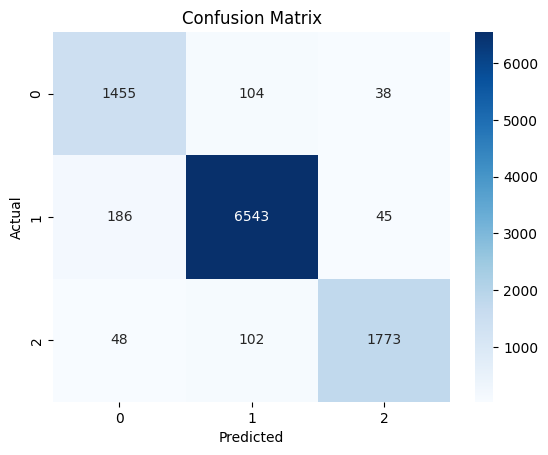

In [39]:
# ============================================================
# FINAL SENTIMENT MODEL — CORRECT, NO LEAKAGE, WELL SCALED
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------
sentiment_df = sentiment_df.dropna(subset=['clean_text']).copy()
sentiment_df.reset_index(drop=True, inplace=True)

sentiment_df['model_text'] = sentiment_df['clean_text'].astype(str)

feature_cols = ['num_words','num_questions','num_exclaims','num_emoji_words']

# ------------------------------------------------------------
# 2. Split BEFORE TF-IDF (no leakage)
# ------------------------------------------------------------
X_train_text, X_test_text, y_train, y_test = train_test_split(
    sentiment_df['model_text'],
    sentiment_df['sentiment_label'],
    test_size=0.2,
    random_state=42,
    stratify=sentiment_df['sentiment_label']
)

# ------------------------------------------------------------
# 3. TF-IDF (FIT ONLY ON TRAIN)
# ------------------------------------------------------------
tfidf = TfidfVectorizer(
    max_features=6000,
    ngram_range=(1, 2),
    token_pattern=r'(?u)\b\w+\b'
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

# ------------------------------------------------------------
# 4. Scale numeric features
# ------------------------------------------------------------
scaler = StandardScaler()

X_train_num = scaler.fit_transform(
    sentiment_df.loc[X_train_text.index, feature_cols]
)
X_test_num = scaler.transform(
    sentiment_df.loc[X_test_text.index, feature_cols]
)

# Convert numeric to sparse
X_train_num = csr_matrix(X_train_num)
X_test_num = csr_matrix(X_test_num)

# ------------------------------------------------------------
# 5. Combine TF-IDF + numeric
# ------------------------------------------------------------
X_train = hstack([X_train_tfidf, X_train_num])
X_test = hstack([X_test_tfidf, X_test_num])

# ------------------------------------------------------------
# 6. Logistic Regression (tuned for sparse)
# ------------------------------------------------------------
model = LogisticRegression(
    solver='saga',
    max_iter=3000,
    C=0.5,
    class_weight='balanced',
    n_jobs=-1
)

model.fit(X_train, y_train)

# ------------------------------------------------------------
# 7. Evaluate
# ------------------------------------------------------------
y_pred = model.predict(X_test)

print("=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_test, y_pred))

print("\n=== CONFUSION MATRIX ===\n")
print(confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
sentiment_df[['model_text','sentiment_label']].tail(10)

,model_text,sentiment_label
51420,ለማስጀመር ሚለውን የምነካው?,neutral
51421,ጋሸና አካባቢው network ከተዘጋ ሳምንት አለፈው መላ በሉን,negative
51422,ምንም ሳልጠቀም አልቋልም አላለኝም እንዲሁ አሁንም አለ ተጨማሪ ስገዛ ስራ...,neutral
51423,ekyc መተግበሪያ እንዴት ነው ማዘመን ምችለው ስልኬ ላይ?,neutral
51424,safaricom sime dataye ሲያልቅ birr አይበላብኝም ነበር ከዚ...,negative
51425,hello monthly wifi kefeye nebre network alemta...,neutral
51426,ካርድ ስጠይቅ ሜሴጅ መምጣቱን ትቶ flash sms ብሎ ነው የሚመጣ እና ...,negative
51427,የሳፋሪኮም ጥቅል ወደ ኢቴዮ ቴሊ መገልበጥ አይቻልም ?,negative
51428,face_with_open_eyes_and_hand_over_mouth,positive
51429,fuck safaricom working internet number,neutral


In [ ]:
from transformers import pipeline
from tqdm import tqdm

# Faster & lighter model (recommended now)
classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/multilingual-MiniLMv2-L6-mnli-xnli",   # small & fast
    device=-1,          # -1 = CPU, 0 = GPU if have
    batch_size=32
)

candidate_labels = ["positive", "negative", "neutral"]

texts = sentiment_df['clean_text'].astype(str).fillna("").tolist()

results = []
for i in tqdm(range(0, len(texts), 32)):
    batch = texts[i:i+32]
    out = classifier(batch, candidate_labels=candidate_labels, truncation=True, max_length=256)
    results.extend([r['labels'][0] for r in out])

sentiment_df['zero_shot_sentiment'] = results

print("✅ Done with fast model")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: MoritzLaurer/multilingual-MiniLMv2-L6-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
  9%|▉         | 141/1609 [03:09<32:48,  1.34s/it]  


KeyboardInterrupt: 

In [ ]:
from transformers import pipeline
from tqdm import tqdm
intent_classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/multilingual-MiniLMv2-L6-mnli-xnli",
    device=-1,
    batch_size=32
)

candidate_labels = ["supportive", "critical", "inquisitive"]

texts = sentiment_df['clean_text'].astype(str).fillna("").tolist()

results = []

for i in tqdm(range(0, len(texts), 32)):
    batch = texts[i:i+32]

    out = intent_classifier(
        batch,
        candidate_labels=candidate_labels,
        truncation=True,
        max_length=256
    )

    results.extend([r['labels'][0] for r in out])

sentiment_df['zero_shot_intent'] = results

print("✅ Intent/Emotion classification done")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: MoritzLaurer/multilingual-MiniLMv2-L6-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 1609/1609 [42:37<00:00,  1.59s/it]  

✅ Intent/Emotion classification done


In [ ]:
from transformers import pipeline
from tqdm import tqdm

tox_classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/multilingual-MiniLMv2-L6-mnli-xnli",
    device=-1,
    batch_size=32
)

candidate_labels = ["clean", "provocative", "hazardous"]

texts = sentiment_df['clean_text'].astype(str).fillna("").tolist()

results = []

for i in tqdm(range(0, len(texts), 32)):
    batch = texts[i:i+32]

    out = tox_classifier(
        batch,
        candidate_labels=candidate_labels,
        truncation=True,
        max_length=256
    )

    results.extend([r['labels'][0] for r in out])

sentiment_df['zero_shot_toxicity'] = results

print("✅ Toxicity classification done")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: MoritzLaurer/multilingual-MiniLMv2-L6-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 1609/1609 [42:09<00:00,  1.57s/it]  

✅ Toxicity classification done


In [ ]:
print(sentiment_df[['clean_text', 'zero_shot_sentiment','zero_shot_intent','zero_shot_toxicity']].head(10))
# Save to CSV (most common)
sentiment_df[['clean_text', 'zero_shot_sentiment','zero_shot_intent','zero_shot_toxicity']].to_csv('sentiment_full.csv', index=False)

                                          clean_text zero_shot_sentiment  \
0  እካ ሰላምታ በምንትያ በዳጣ ምናለ በዳጣ ካስደሰኳቹ ሸልሙኝ ዳታ beami...            positive   
1  እንካ ሰላምታበምንቲያ  በ ገርጂ ምን አለ በ ገርጂ  ምንድነው እንዲ መፈ...            negative   
2  please let know download use sefericom ethiopi...            negative   
3        እካ ስለምንትያ በምንትያ በውዲቷ ሀገር በሳፋሪ ዳታ ዘና ብለህ እደር            positive   
4  እንካ ሰላምታበምንትያ በሳፋሪኮም ምናለ በሳፋሪኮም ፈጣን ኢንተርኔት ሰቶን...            positive   
5  እንካ ሰላምታ በምንንትያ በ pessa ምን አለ በ pessa ያለው ሰርፕራ...            positive   
6  ይህን ውድድር ያሸነፈ ሰው mifi ነዋ የሚሸለመው smilingfacewit...             neutral   
7                       mpesaን እጠቀማለሁ ግን አልተሸለኩም why            negative   
8                                          የምን ጎተ ነዉ            positive   
9                                           thumbsup            negative   

  zero_shot_intent zero_shot_toxicity  
0      inquisitive          hazardous  
1      inquisitive          hazardous  
2      inquisitive        provocative  
3  

In [ ]:
# ============================================================
# PROPORTIONAL STRATIFIED SAMPLING (15,000) — NO STRATA COLUMN
# Stratify by: zero_shot_sentiment
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Keep only required columns
# ------------------------------------------------------------
cols = [
    'clean_text',
    'zero_shot_sentiment',
    'zero_shot_intent',
    'zero_shot_toxicity'
]

df = sentiment_df[cols].dropna().copy()
print("Original dataset shape:", df.shape)

TOTAL_SAMPLES = 15000

# ------------------------------------------------------------
# 2. Stratified sampling by sentiment (proportional)
# ------------------------------------------------------------
def stratified_sample(data, label_col, total_n, random_state=42):
    proportions = data[label_col].value_counts(normalize=True)
    samples = []

    for label, prop in proportions.items():
        n = int(round(prop * total_n))
        subset = data[data[label_col] == label]
        n = min(n, len(subset))  # safety
        samples.append(subset.sample(n=n, random_state=random_state))

    result = pd.concat(samples)

    # Adjust to exactly TOTAL_SAMPLES
    if len(result) > total_n:
        result = result.sample(total_n, random_state=random_state)
    elif len(result) < total_n:
        extra = data.sample(total_n - len(result), random_state=random_state)
        result = pd.concat([result, extra])

    return result.reset_index(drop=True)


sample_15k = stratified_sample(
    df,
    label_col='zero_shot_sentiment',
    total_n=TOTAL_SAMPLES
)

# ------------------------------------------------------------
# 3. Final shuffle
# ------------------------------------------------------------
sample_15k = sample_15k.sample(frac=1, random_state=42).reset_index(drop=True)

# ------------------------------------------------------------
# 4. Save
# ------------------------------------------------------------
sample_15k.to_csv(
    "multi_task_15k_for_manual_labeling.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ Saved: multi_task_15k_for_manual_labeling.csv")
print("Final shape:", sample_15k.shape)

# ------------------------------------------------------------
# 5. Check distributions (all three layers)
# ------------------------------------------------------------
print("\nSentiment distribution:")
print(sample_15k['zero_shot_sentiment'].value_counts(normalize=True))

print("\nIntent distribution:")
print(sample_15k['zero_shot_intent'].value_counts(normalize=True))

print("\nToxicity distribution:")
print(sample_15k['zero_shot_toxicity'].value_counts(normalize=True))

Original dataset shape: (51470, 4)

✅ Saved: multi_task_15k_for_manual_labeling.csv
Final shape: (15000, 4)

Sentiment distribution:
zero_shot_sentiment
positive    0.649600
negative    0.272733
neutral     0.077667
Name: proportion, dtype: float64

Intent distribution:
zero_shot_intent
inquisitive    0.7978
supportive     0.1900
critical       0.0122
Name: proportion, dtype: float64

Toxicity distribution:
zero_shot_toxicity
provocative    0.562533
hazardous      0.350267
clean          0.087200
Name: proportion, dtype: float64
